Import Packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

Load Data

In [ ]:
mRNA = pd.read_csv("../results/tables/lasso_cox_cv_results.csv")
multi = pd.read_csv("../results/tables/lasso_cox_multiomics_cv_results.csv")

mRNA["model"] = "mRNA-only"
multi["model"] = "Multi-omics"



Wilcoxon Rank Test of C-Indexes

In [6]:
wilcoxon(mRNA["test_c_index"], multi["test_c_index"])

WilcoxonResult(statistic=np.float64(6.0), pvalue=np.float64(0.8125))

Wilcoxon signed-rank test showed no significant difference in predictive performance between the mRNA-only and multi-omics models (p = 0.81), indicating that the observed improvement in mean C-index is not statistically robust across cross-validation folds.

Create Combined Data Frame

In [7]:
combined_df = pd.concat([mRNA, multi], ignore_index=True)

In [9]:
combined_df

,fold,alpha,n_features_total,n_features_selected,test_c_index,n_test,model
0,1,0.000595,50,47,0.603361,112,mRNA-only
1,2,0.016459,50,9,0.506608,111,mRNA-only
2,3,0.022329,50,4,0.479730,111,mRNA-only
3,4,0.000609,50,44,0.685294,111,mRNA-only
4,5,0.009420,50,15,0.459290,111,mRNA-only
5,1,0.007088,577,100,0.490756,112,Multi-omics
6,2,0.010288,577,80,0.632159,111,Multi-omics
7,3,0.000531,577,541,0.619932,111,Multi-omics
8,4,0.000974,577,524,0.552941,111,Multi-omics
9,5,0.006468,577,104,0.528184,111,Multi-omics


Create short descriptive summary

In [29]:
summary = combined_df.groupby("model")["test_c_index"].agg(["mean", "std"]).reset_index()
print(summary)

         model      mean       std
0  Multi-omics  0.564794  0.060292
1    mRNA-only  0.546857  0.095068


Visualize the C-Indexes

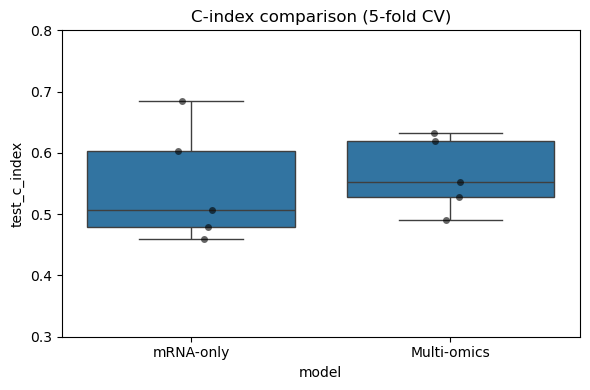

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=combined_df, x="model", y="test_c_index")
sns.stripplot(data=combined_df, x="model", y="test_c_index", color="black", alpha=0.6)

plt.title("C-index comparison (5-fold CV)")
plt.ylim(0.3, 0.8)
plt.tight_layout()

#plt.savefig("../results/figures/cindex_boxplot.png", dpi=300)
#plt.close()


Visualize the Mean and SDs

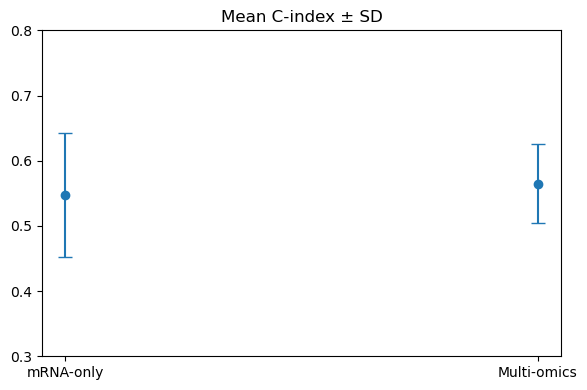

In [27]:
# Sort the factor levels of model for better comparability

summary["model"] = pd.Categorical(
    summary["model"],
    categories=["mRNA-only", "Multi-omics"],
    ordered=True
)

summary = summary.sort_values("model")


plt.figure(figsize=(6,4))

plt.errorbar(
    summary["model"],
    summary["mean"],
    yerr=summary["std"],
    fmt="o",
    capsize=5
)

plt.title("Mean C-index ± SD")
plt.ylim(0.3, 0.8)
plt.tight_layout()
#plt.savefig("results/figures/cindex_mean_sd.png", dpi=300)
#plt.close()

Visualize Feature Selection Stability

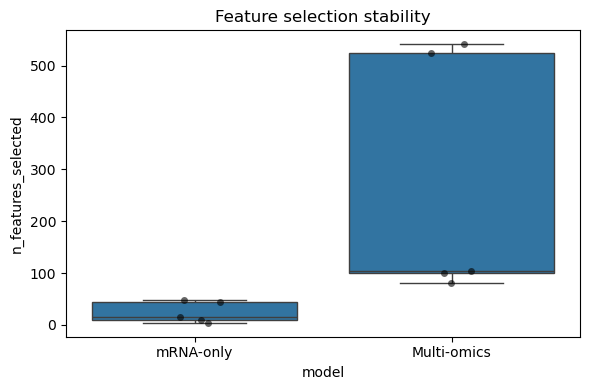

In [28]:
plt.figure(figsize=(6,4))

sns.boxplot(data=combined_df, x="model", y="n_features_selected")
sns.stripplot(data=combined_df, x="model", y="n_features_selected",
              color="black", alpha=0.6, jitter=True)

plt.title("Feature selection stability")
plt.tight_layout()
#plt.savefig("results/figures/feature_selection_comparison.png", dpi=300)
#plt.close()